In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
from architecture import VAE
import torch
import math


In [3]:
train_ds = datasets.FashionMNIST(root="fminst",
                                 train=True,
                                 download=True,
                                    transform=transforms.ToTensor())
test_ds = datasets.FashionMNIST(root="fminst",
                                train=False,
                                download=True,
                                   transform=transforms.ToTensor())


In [4]:
print(len(train_ds), len(test_ds))

60000 10000


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VAE(latent_dim=20).to(device)

def vae_loss(x_recon, x, mu, logvar):
    # MSE reconstruction loss + KL divergence
    recon = F.mse_loss(x_recon, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl


In [6]:
batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 10
warmup_epochs = 3  # KL warm-up

train_losses = []
val_losses = []
train_recon = []
train_kl = []
val_recon = []
val_kl = []

for epoch in range(1, epochs + 1):
    # Linear KL annealing from 0 -> 1
    beta = min(1.0, epoch / max(1, warmup_epochs))

    model.train()
    total_train = 0.0
    total_train_recon = 0.0
    total_train_kl = 0.0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        x_recon, mu, logvar = model(x)
        recon = F.mse_loss(x_recon, x, reduction='sum')
        kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon + beta * kl
        loss.backward()
        optimizer.step()
        total_train += loss.item()
        total_train_recon += recon.item()
        total_train_kl += kl.item()
    avg_train = total_train / len(train_loader.dataset)
    avg_train_recon = total_train_recon / len(train_loader.dataset)
    avg_train_kl = total_train_kl / len(train_loader.dataset)
    train_losses.append(avg_train)
    train_recon.append(avg_train_recon)
    train_kl.append(avg_train_kl)

    model.eval()
    total_val = 0.0
    total_val_recon = 0.0
    total_val_kl = 0.0
    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)
            x_recon, mu, logvar = model(x)
            recon = F.mse_loss(x_recon, x, reduction='sum')
            kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss = recon + beta * kl
            total_val += loss.item()
            total_val_recon += recon.item()
            total_val_kl += kl.item()
    avg_val = total_val / len(val_loader.dataset)
    avg_val_recon = total_val_recon / len(val_loader.dataset)
    avg_val_kl = total_val_kl / len(val_loader.dataset)
    val_losses.append(avg_val)
    val_recon.append(avg_val_recon)
    val_kl.append(avg_val_kl)

    print(f'Epoch {epoch}/{epochs} - beta: {beta:.2f} - train: {avg_train:.4f} - val: {avg_val:.4f} - train_kl: {avg_train_kl:.4f} - val_kl: {avg_val_kl:.4f}')


Epoch 1/5 - train loss: 38.7958 - val loss: 28.3988
Epoch 2/5 - train loss: 27.1045 - val loss: 26.4198
Epoch 3/5 - train loss: 25.7995 - val loss: 25.3796
Epoch 4/5 - train loss: 25.1312 - val loss: 24.9534
Epoch 5/5 - train loss: 24.7236 - val loss: 24.7833


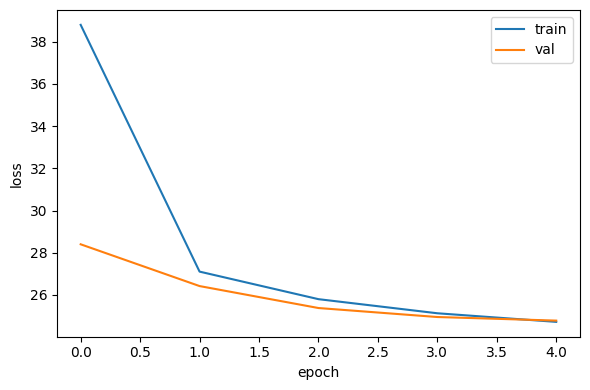

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.tight_layout()
plt.show()


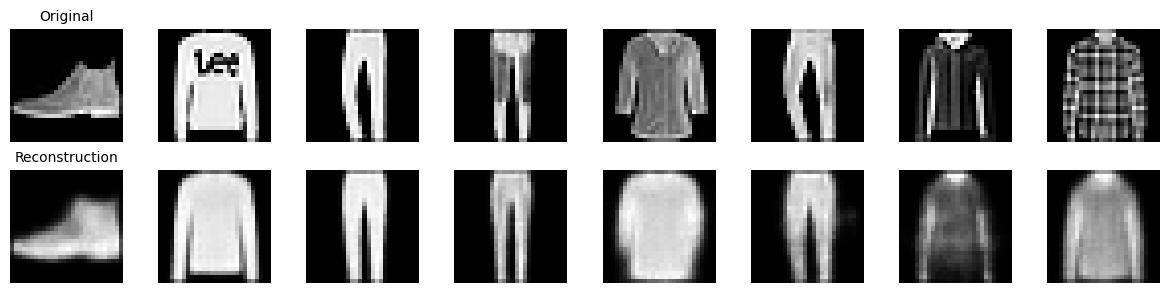

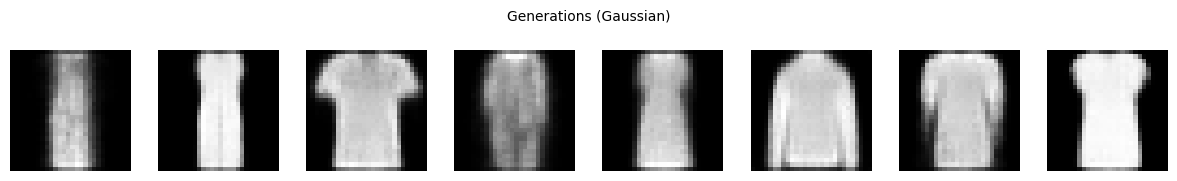

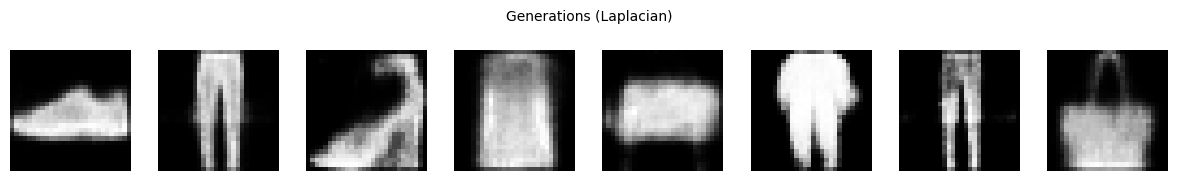

In [8]:
def show_reconstructions(model, loader, n=8):
    model.eval()
    with torch.no_grad():
        x, _ = next(iter(loader))
        x = x[:n].to(device)
        x_recon, _, _ = model(x)

    x = x.cpu()
    x_recon = x_recon.cpu()
    fig, axes = plt.subplots(2, n, figsize=(n*1.5, 3))
    for i in range(n):
        axes[0, i].imshow(x[i, 0], cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(x_recon[i, 0], cmap='gray')
        axes[1, i].axis('off')
    axes[0, 0].set_title('Original', fontsize=10)
    axes[1, 0].set_title('Reconstruction', fontsize=10)
    plt.tight_layout()
    plt.show()

def show_generations(model, n=8, prior='normal', scale=1.0):
    model.eval()
    with torch.no_grad():
        if prior == 'normal':
            z = torch.randn(n, model.fc_mu.out_features, device=device) * scale
        elif prior == 'laplace':
            # Laplace(0, scale): sample via inverse CDF
            u = torch.rand(n, model.fc_mu.out_features, device=device) - 0.5
            z = -scale * torch.sign(u) * torch.log1p(-2 * torch.abs(u))
        else:
            raise ValueError('prior must be normal or laplace')
        x_gen = model.decode(z).cpu()

    fig, axes = plt.subplots(1, n, figsize=(n*1.5, 1.8))
    for i in range(n):
        axes[i].imshow(x_gen[i, 0], cmap='gray')
        axes[i].axis('off')
    title = 'Generations (Gaussian)' if prior == 'normal' else 'Generations (Laplacian)'
    plt.suptitle(title, fontsize=10)
    plt.tight_layout()
    plt.show()

# Reconstructions
show_reconstructions(model, val_loader, n=8)

# Generations from Gaussian prior
show_generations(model, n=8, prior='normal')

# Generations from Laplacian prior
show_generations(model, n=8, prior='laplace')


In [9]:
def elbo_components(model, loader):
    model.eval()
    total_recon = 0.0
    total_kl = 0.0
    mu_mean = 0.0
    logvar_mean = 0.0
    n = 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            x_recon, mu, logvar = model(x)
            recon = F.mse_loss(x_recon, x, reduction='sum')
            kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            total_recon += recon.item()
            total_kl += kl.item()
            mu_mean += mu.mean().item() * x.size(0)
            logvar_mean += logvar.mean().item() * x.size(0)
            n += x.size(0)
    avg_recon = total_recon / n
    avg_kl = total_kl / n
    mu_mean /= n
    logvar_mean /= n
    return avg_recon, avg_kl, mu_mean, logvar_mean

avg_recon, avg_kl, mu_mean, logvar_mean = elbo_components(model, val_loader)
print(f'Avg recon (per sample): {avg_recon:.4f}')
print(f'Avg KL (per sample): {avg_kl:.4f}')
print(f'Mean(mu): {mu_mean:.4f} | Mean(logvar): {logvar_mean:.4f}')

# Heuristic collapse checks
if avg_kl < 1.0:
    print('KL is very small; possible posterior collapse.')
else:
    print('KL is non-trivial; posterior likely not fully collapsed.')


Avg recon (per sample): 17.2834
Avg KL (per sample): 7.4831
Mean(mu): 0.0077 | Mean(logvar): -0.7400
KL is non-trivial; posterior likely not fully collapsed.
